1、向量点积 a·b

a·b = 2×1 + (-1)×4 + 3×(-2) = 2 - 4 - 6 = -8

答案：-8

2、矩阵乘法 A×B

A形状：2×3，B形状：3×2，结果形状：2×2

计算过程：
第1行第1列：1×2 + 0×0 + 2×3 = 2+0+6 = 8
第1行第2列：1×1 + 0×(-1) + 2×2 = 1+0+4 = 5
第2行第1列：(-1)×2 + 3×0 + 1×3 = -2+0+3 = 1
第2行第2列：(-1)×1 + 3×(-1) + 1×2 = -1-3+2 = -2

结果：
A×B = [ [8, 5], [1, -2] ]

3、向量a的Frobenius范数

‖a‖F = √(2² + (-1)² + 3²) = √(4+1+9) = √14 ≈ 3.7417



In [4]:
import numpy as np

# 1. 创建形状为 3x4 的随机矩阵 X，元素服从标准正态分布
X = np.random.randn(3, 4)

# 2. 创建形状为 4x2 的全 1 矩阵 Y
Y = np.ones((4, 2))

# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)  # 或 X @ Y

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素
element_1_2 = Z[0, 1]  # 第一行第二列（索引从0开始）
row_2 = Z[1, :]        # 第二行所有元素

print("Z =")
print(Z)
print("\nZ 的第一行第二列元素:", element_1_2)
print("Z 的第二行所有元素:", row_2)

# 5. 计算 Z 的 Frobenius 范数
frobenius_norm = np.linalg.norm(Z, 'fro')
print("\nZ 的 Frobenius 范数:", frobenius_norm)

Z =
[[-3.95852333 -3.95852333]
 [-3.01891156 -3.01891156]
 [-0.11734751 -0.11734751]]

Z 的第一行第二列元素: -3.9585233348457693
Z 的第二行所有元素: [-3.01891156 -3.01891156]

Z 的 Frobenius 范数: 7.042372393759984


已知：
患病率 P(病) = 0.1% = 0.001
灵敏度 P(阳|病) = 99% = 0.99
假阳性率 P(阳|无病) = 2% = 0.02

求：P(病|阳) = ?

解（贝叶斯公式）：

P(病|阳) = P(阳|病) × P(病) / P(阳)

其中 P(阳) = P(阳|病)×P(病) + P(阳|无病)×P(无病)

P(无病) = 1 - P(病) = 1 - 0.001 = 0.999

P(阳) = 0.99 × 0.001 + 0.02 × 0.999
= 0.00099 + 0.01998
= 0.02097

P(病|阳) = 0.00099 / 0.02097
≈ 0.04721

答案：约 4.72%

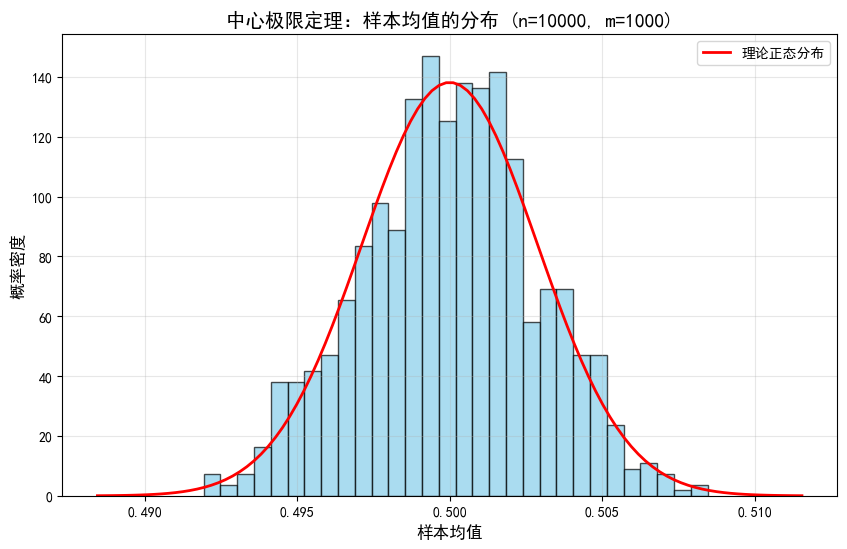

=== 中心极限定理模拟结果 ===
样本均值的实际均值: 0.499992
理论均值: 0.500000
样本均值的实际方差: 0.00000828
理论方差: 0.00000833
实际标准差: 0.002877
理论标准差: 0.002887


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 方案1：使用系统自带中文字体（Windows）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False

# 方案2：如果上面不行，尝试（macOS）
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']

# 方案3：如果还不行，使用（Linux）
# plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']

# 设置随机种子
np.random.seed(42)

# 参数设置
n = 10000
m = 1000

# 1. 生成样本均值
sample_means = [np.mean(np.random.uniform(0, 1, n)) for _ in range(m)]
sample_means = np.array(sample_means)

# 2. 绘图
plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')

mu_theory = 0.5
sigma_theory = np.sqrt((1/12) / n)
x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 100)
y = stats.norm.pdf(x, mu_theory, sigma_theory)
plt.plot(x, y, 'r-', linewidth=2, label='理论正态分布')

plt.xlabel('样本均值', fontsize=12)
plt.ylabel('概率密度', fontsize=12)
plt.title('中心极限定理：样本均值的分布 (n=10000, m=1000)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. 计算方差
actual_variance = np.var(sample_means)
theoretical_variance = (1/12) / n

print("=== 中心极限定理模拟结果 ===")
print(f"样本均值的实际均值: {np.mean(sample_means):.6f}")
print(f"理论均值: {mu_theory:.6f}")
print(f"样本均值的实际方差: {actual_variance:.8f}")
print(f"理论方差: {theoretical_variance:.8f}")
print(f"实际标准差: {np.std(sample_means):.6f}")
print(f"理论标准差: {sigma_theory:.6f}")

1、计算偏导数表达式

令 u = w1·x1 + w2·x2 - y
则 z = u^2

由链式法则：
∂z/∂w1 = ∂z/∂u × ∂u/∂w1 = 2u × x1

∂z/∂w2 = ∂z/∂u × ∂u/∂w2 = 2u × x2

代入 x1=2, x2=1：

∂z/∂w1 = 2u × 2 = 4u
∂z/∂w2 = 2u × 1 = 2u

其中 u = 2w1 + 1w2 - 3 = 2w1 + w2 - 3

所以：
∂z/∂w1 = 4(2w1 + w2 - 3)
∂z/∂w2 = 2(2w1 + w2 - 3)

2、代入 w1=0.5, w2=1 计算梯度

u = 2×0.5 + 1 - 3 = 1 + 1 - 3 = -1

∂z/∂w1 = 4 × (-1) = -4
∂z/∂w2 = 2 × (-1) = -2

答案：梯度为 [-4, -2]

In [8]:
import torch

# ========== 手动实现前向和反向传播 ==========
print("=== 手动实现计算图的反向传播 ===\n")

# 给定参数
x = 2
w1 = 1.5
w2 = 0.5

# 1. 前向计算
# a = x * w1
a = x * w1
print(f"1. 前向计算:")
print(f"   a = x * w1 = {x} × {w1} = {a}")

# b = a + w2
b = a + w2
print(f"   b = a + w2 = {a} + {w2} = {b}")

# L = b^2
L = b ** 2
print(f"   L = b^2 = {b}^2 = {L}\n")

# 2. 手动按链式法则计算梯度
# ∂L/∂b = 2b
dL_db = 2 * b
print(f"2. 手动计算梯度（链式法则）:")

# ∂b/∂a = 1, ∂b/∂w2 = 1
# ∂a/∂w1 = x, ∂a/∂x = w1（但x是常量，不需求导）

# ∂L/∂w1 = ∂L/∂b × ∂b/∂a × ∂a/∂w1 = dL_db × 1 × x
dL_dw1 = dL_db * x
print(f"   ∂L/∂w1 = ∂L/∂b × ∂b/∂a × ∂a/∂w1 = {dL_db} × 1 × {x} = {dL_dw1}")

# ∂L/∂w2 = ∂L/∂b × ∂b/∂w2 = dL_db × 1
dL_dw2 = dL_db * 1
print(f"   ∂L/∂w2 = ∂L/∂b × ∂b/∂w2 = {dL_db} × 1 = {dL_dw2}\n")

# 3. 使用 PyTorch 自动微分验证
print(f"3. PyTorch 自动微分验证:")

# 定义需要梯度的变量
x_t = torch.tensor(2.0, requires_grad=False)  # 常量
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)

# 前向计算
a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

# 反向传播
L_t.backward()

print(f"   PyTorch 计算的 ∂L/∂w1 = {w1_t.grad.item()}")
print(f"   PyTorch 计算的 ∂L/∂w2 = {w2_t.grad.item()}")

# 验证一致性
print(f"\n验证结果:")
if abs(dL_dw1 - w1_t.grad.item()) < 1e-6 and abs(dL_dw2 - w2_t.grad.item()) < 1e-6:
    print("   ✓ 手动计算的梯度与自动微分结果完全一致！")
else:
    print("   ✗ 结果不一致，请检查计算")

=== 手动实现计算图的反向传播 ===

1. 前向计算:
   a = x * w1 = 2 × 1.5 = 3.0
   b = a + w2 = 3.0 + 0.5 = 3.5
   L = b^2 = 3.5^2 = 12.25

2. 手动计算梯度（链式法则）:
   ∂L/∂w1 = ∂L/∂b × ∂b/∂a × ∂a/∂w1 = 7.0 × 1 × 2 = 14.0
   ∂L/∂w2 = ∂L/∂b × ∂b/∂w2 = 7.0 × 1 = 7.0

3. PyTorch 自动微分验证:
   PyTorch 计算的 ∂L/∂w1 = 14.0
   PyTorch 计算的 ∂L/∂w2 = 7.0

验证结果:
   ✓ 手动计算的梯度与自动微分结果完全一致！


已知：L = (1/n) × Σ(yi - (w·xi + b))^2，其中 i = 1 到 n

令预测值 ŷi = w·xi + b
则 L = (1/n) × Σ(yi - ŷi)^2 = (1/n) × Σ(residual_i)^2

推导 ∂L/∂w：

由链式法则：
∂L/∂w = (1/n) × Σ 2(yi - ŷi) × ∂(yi - ŷi)/∂w
= (1/n) × Σ 2(yi - ŷi) × (-∂ŷi/∂w)
= (1/n) × Σ 2(yi - ŷi) × (-xi)
= -(2/n) × Σ xi(yi - ŷi)

所以：∂L/∂w = -(2/n) × Σ xi(yi - (w·xi + b))

推导 ∂L/∂b：

∂L/∂b = (1/n) × Σ 2(yi - ŷi) × ∂(yi - ŷi)/∂b
= (1/n) × Σ 2(yi - ŷi) × (-∂ŷi/∂b)
= (1/n) × Σ 2(yi - ŷi) × (-1)
= -(2/n) × Σ (yi - ŷi)

所以：∂L/∂b = -(2/n) × Σ (yi - (w·xi + b))

最终表达式（求和形式）：

∂L/∂w = -(2/n) × Σ [ xi × (yi - w·xi - b) ]

∂L/∂b = -(2/n) × Σ (yi - w·xi - b)

其中 Σ 表示 i=1 到 n 的求和。

=== Softmax 回归分类 MNIST（digits数据集）===

训练集大小: 1437 样本
测试集大小: 360 样本
特征维度: 64
类别数: 10

开始训练...
Epoch 10/50, Loss: 0.3301, Test Accuracy: 0.9000
Epoch 20/50, Loss: 0.0993, Test Accuracy: 0.9694
Epoch 30/50, Loss: 0.1041, Test Accuracy: 0.9444
Epoch 40/50, Loss: 0.0014, Test Accuracy: 0.9694
Epoch 50/50, Loss: 0.0002, Test Accuracy: 0.9694

=== 训练完成 ===
测试集最终准确率: 0.9694 (96.94%)


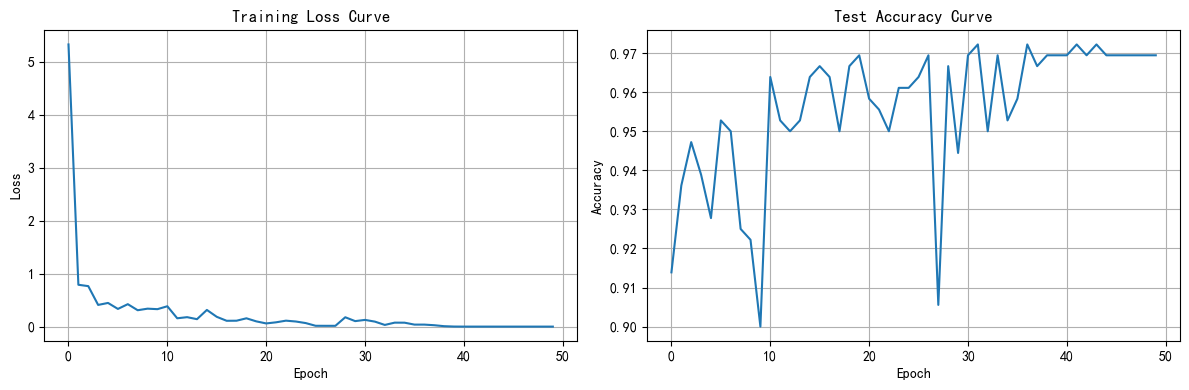


=== 预测示例（前10个测试样本）===
样本 1: 预测=6, 真实=6 ✓
样本 2: 预测=9, 真实=9 ✓
样本 3: 预测=3, 真实=3 ✓
样本 4: 预测=7, 真实=7 ✓
样本 5: 预测=2, 真实=2 ✓
样本 6: 预测=1, 真实=1 ✓
样本 7: 预测=5, 真实=5 ✓
样本 8: 预测=2, 真实=2 ✓
样本 9: 预测=5, 真实=5 ✓
样本 10: 预测=2, 真实=2 ✓


In [9]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(42)

# ========== 1. 加载数据 ==========
print("=== Softmax 回归分类 MNIST（digits数据集）===\n")
digits = load_digits()
X = digits.images  # (1797, 8, 8)
y = digits.target  # (1797,)

# 将图像展平为向量（8×8=64维）
X = X.reshape(X.shape[0], -1)  # (1797, 64)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"训练集大小: {X_train.shape[0]} 样本")
print(f"测试集大小: {X_test.shape[0]} 样本")
print(f"特征维度: {X_train.shape[1]}")
print(f"类别数: {len(np.unique(y))}\n")

# ========== 2. One-hot 编码标签 ==========
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

num_classes = y_train_onehot.shape[1]
num_features = X_train.shape[1]

# ========== 3. 实现 Softmax 和交叉熵损失 ==========
def softmax(logits):
    """Softmax 函数，输入形状 (n_samples, n_classes)"""
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))  # 数值稳定
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    """交叉熵损失，y_pred 是概率，y_true 是 one-hot"""
    n_samples = y_pred.shape[0]
    # 避免 log(0)
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / n_samples
    return loss

# ========== 4. 模型训练 ==========
class SoftmaxRegression:
    def __init__(self, num_features, num_classes, learning_rate=0.1):
        # 初始化权重和偏置
        self.W = np.random.randn(num_features, num_classes) * 0.01
        self.b = np.zeros((1, num_classes))
        self.lr = learning_rate
    
    def forward(self, X):
        """前向传播: logits = X·W + b"""
        return np.dot(X, self.W) + self.b
    
    def backward(self, X, y_true, y_pred):
        """反向传播计算梯度"""
        n_samples = X.shape[0]
        
        # 梯度: ∂L/∂logits = y_pred - y_true (softmax + 交叉熵的梯度)
        dlogits = y_pred - y_true
        
        # ∂L/∂W = (1/n) * X^T · dlogits
        dW = np.dot(X.T, dlogits) / n_samples
        
        # ∂L/∂b = (1/n) * sum(dlogits, axis=0)
        db = np.sum(dlogits, axis=0, keepdims=True) / n_samples
        
        return dW, db
    
    def update(self, dW, db):
        """梯度下降更新参数"""
        self.W -= self.lr * dW
        self.b -= self.lr * db
    
    def predict(self, X):
        """预测类别"""
        logits = self.forward(X)
        probs = softmax(logits)
        return np.argmax(probs, axis=1)

# 训练参数
batch_size = 32
learning_rate = 0.1
epochs = 50

# 初始化模型
model = SoftmaxRegression(num_features, num_classes, learning_rate)

# 训练循环
train_losses = []
test_accuracies = []

print("开始训练...")
for epoch in range(epochs):
    # 小批量随机梯度下降
    indices = np.random.permutation(X_train.shape[0])
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    epoch_loss = 0
    num_batches = 0
    
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向传播
        logits = model.forward(X_batch)
        probs = softmax(logits)
        
        # 计算损失
        loss = cross_entropy_loss(probs, y_batch)
        epoch_loss += loss
        num_batches += 1
        
        # 反向传播
        dW, db = model.backward(X_batch, y_batch, probs)
        
        # 更新参数
        model.update(dW, db)
    
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    
    # 测试准确率
    y_pred = model.predict(X_test)
    accuracy = np.mean(y_pred == y_test)
    test_accuracies.append(accuracy)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.4f}")

# 最终结果
print("\n=== 训练完成 ===")
y_pred_final = model.predict(X_test)
final_accuracy = np.mean(y_pred_final == y_test)
print(f"测试集最终准确率: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")

# 绘制训练曲线
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(test_accuracies)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy Curve')
plt.grid(True)

plt.tight_layout()
plt.show()

# 展示一些预测结果
print("\n=== 预测示例（前10个测试样本）===")
for i in range(10):
    pred = y_pred_final[i]
    true = y_test[i]
    status = "✓" if pred == true else "✗"
    print(f"样本 {i+1}: 预测={pred}, 真实={true} {status}")

已知：x₁, x₂, ..., xn 独立同分布于 N(μ, σ²)

1、似然函数 L(μ, σ²)

正态分布的概率密度函数：
f(x) = 1/√(2πσ²) × exp[-(x-μ)²/(2σ²)]

由于样本独立，似然函数为每个样本密度的乘积：

L(μ, σ²) = ∏(i=1 to n) 1/√(2πσ²) × exp[-(xi-μ)²/(2σ²)]
= (2πσ²)^(-n/2) × exp[-∑(xi-μ)²/(2σ²)]

对数似然函数（更方便求导）：
ℓ(μ, σ²) = ln L = -(n/2)ln(2π) - (n/2)ln(σ²) - ∑(xi-μ)²/(2σ²)

2、证明 μ 的 MLE 为 (1/n)∑xi

对 ℓ 关于 μ 求偏导：
∂ℓ/∂μ = - (1/(2σ²)) × ∑ 2(xi-μ) × (-1) ？逐项推导更清楚：

ℓ = -(n/2)ln(2π) - (n/2)ln(σ²) - (1/(2σ²))∑(xi-μ)²

∂ℓ/∂μ = - (1/(2σ²)) × ∑ 2(xi-μ) × (-1) ？不对，直接对 (xi-μ)² 求导：

∂/∂μ (xi-μ)² = 2(xi-μ) × (-1) = -2(xi-μ)
所以 ∂ℓ/∂μ = - (1/(2σ²)) × ∑ (-2(xi-μ)) = (1/σ²) × ∑(xi-μ)

令 ∂ℓ/∂μ = 0：
(1/σ²) × ∑(xi-μ) = 0
∑(xi-μ) = 0
∑xi - nμ = 0
μ = (1/n)∑xi

所以 μ 的 MLE：μ̂ = (1/n)∑xi

3、证明 σ² 的 MLE 为 (1/n)∑(xi - μ̂)²

对 ℓ 关于 σ² 求偏导。令 θ = σ²：

ℓ = -(n/2)ln(2π) - (n/2)lnθ - (1/(2θ))∑(xi-μ)²

∂ℓ/∂θ = -n/(2θ) + (1/(2θ²))∑(xi-μ)²

令 ∂ℓ/∂θ = 0：
-n/(2θ) + (1/(2θ²))∑(xi-μ)² = 0
两边乘以 2θ²：
-nθ + ∑(xi-μ)² = 0
nθ = ∑(xi-μ)²
θ = (1/n)∑(xi-μ)²

将 μ 替换为 μ̂ 得到：
σ̂² = (1/n)∑(xi - μ̂)²

注意：这是有偏估计，分母为 n 而非 n-1。

=== 逻辑回归二分类（从零实现）===

训练集大小: 300 样本
测试集大小: 100 样本
特征维度: 2

开始训练...
Iteration 200/1000, Loss: 0.3140
Iteration 400/1000, Loss: 0.3043
Iteration 600/1000, Loss: 0.2997
Iteration 800/1000, Loss: 0.2968
Iteration 1000/1000, Loss: 0.2948

=== 训练完成 ===
测试集准确率: 0.8600 (86.00%)


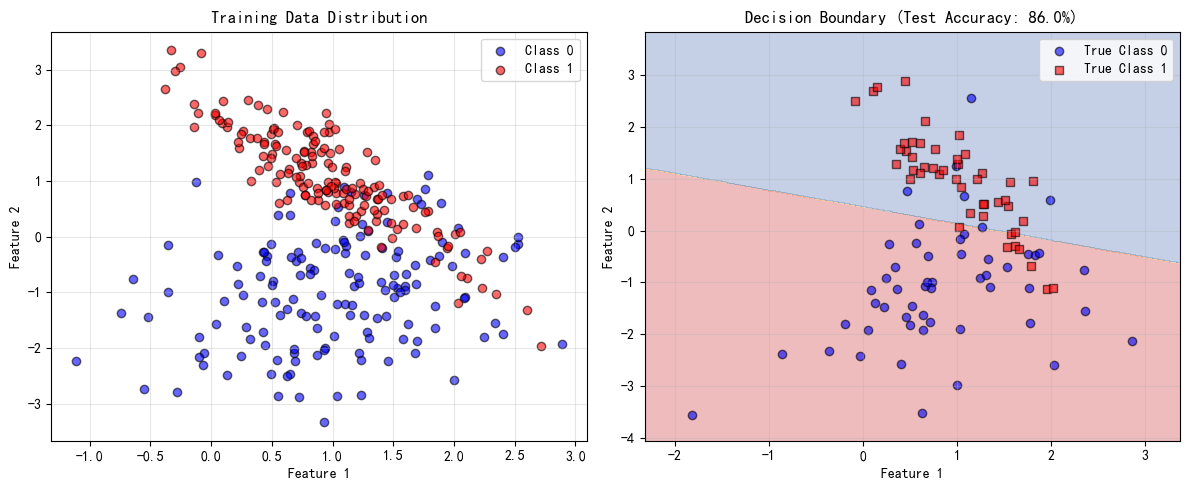

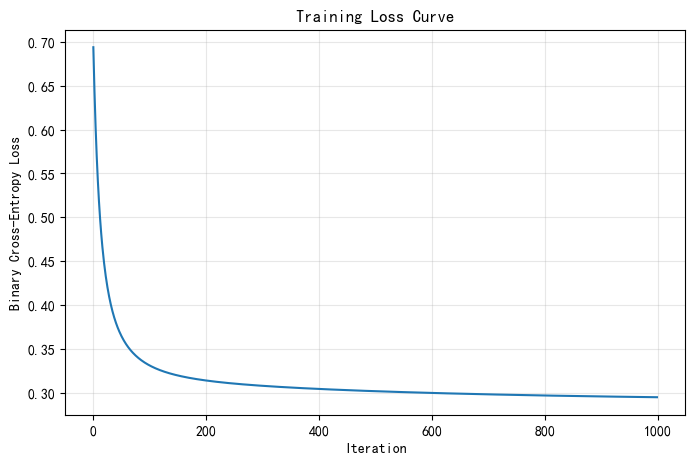


=== 预测示例（前10个测试样本）===
样本 1: 预测=1, 真实=1, 概率=0.8958 ✓
样本 2: 预测=0, 真实=0, 概率=0.0423 ✓
样本 3: 预测=0, 真实=0, 概率=0.3998 ✓
样本 4: 预测=0, 真实=0, 概率=0.0005 ✓
样本 5: 预测=1, 真实=0, 概率=0.7928 ✗
样本 6: 预测=0, 真实=0, 概率=0.0144 ✓
样本 7: 预测=1, 真实=1, 概率=0.9980 ✓
样本 8: 预测=1, 真实=0, 概率=0.9358 ✗
样本 9: 预测=0, 真实=1, 概率=0.4874 ✗
样本 10: 预测=1, 真实=1, 概率=0.5244 ✓


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 设置随机种子
np.random.seed(42)

# ========== 1. 生成线性可分数据 ==========
print("=== 逻辑回归二分类（从零实现）===\n")

# 生成两类线性可分数据，每类200个样本，特征维度2
X, y = make_classification(n_samples=400, n_features=2, n_redundant=0, 
                           n_clusters_per_class=1, flip_y=0, random_state=42)
# 将标签转换为 0 和 1（逻辑回归标准形式）
y = y.reshape(-1, 1)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100, random_state=42)

print(f"训练集大小: {X_train.shape[0]} 样本")
print(f"测试集大小: {X_test.shape[0]} 样本")
print(f"特征维度: {X_train.shape[1]}\n")

# ========== 2. 定义 Sigmoid 和损失函数 ==========
def sigmoid(z):
    """Sigmoid 函数"""
    # 数值稳定处理
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    """二元交叉熵损失"""
    # 避免 log(0)
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

# ========== 3. 梯度下降训练 ==========
class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.W = None
        self.b = None
        self.losses = []
    
    def fit(self, X, y):
        """训练模型"""
        n_samples, n_features = X.shape
        
        # 初始化参数
        self.W = np.random.randn(n_features, 1) * 0.01
        self.b = np.zeros((1, 1))
        
        # 梯度下降
        for i in range(self.n_iterations):
            # 前向传播
            linear_model = np.dot(X, self.W) + self.b
            y_pred = sigmoid(linear_model)
            
            # 计算损失
            loss = binary_cross_entropy(y_pred, y)
            self.losses.append(loss)
            
            # 反向传播（梯度计算）
            # ∂L/∂W = (1/n) * X^T · (y_pred - y)
            dW = np.dot(X.T, (y_pred - y)) / n_samples
            # ∂L/∂b = (1/n) * sum(y_pred - y)
            db = np.sum(y_pred - y) / n_samples
            
            # 更新参数
            self.W -= self.lr * dW
            self.b -= self.lr * db
            
            # 每100次迭代打印损失
            if (i + 1) % 200 == 0:
                print(f"Iteration {i+1}/{self.n_iterations}, Loss: {loss:.4f}")
    
    def predict_proba(self, X):
        """预测概率"""
        linear_model = np.dot(X, self.W) + self.b
        return sigmoid(linear_model)
    
    def predict(self, X, threshold=0.5):
        """预测类别（0或1）"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

# 训练模型
print("开始训练...")
model = LogisticRegression(learning_rate=0.1, n_iterations=1000)
model.fit(X_train, y_train)

# 测试集准确率
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"\n=== 训练完成 ===")
print(f"测试集准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")

# ========== 4. 绘制决策边界 ==========
plt.figure(figsize=(12, 5))

# 绘制训练数据分布
plt.subplot(1, 2, 1)
plt.scatter(X_train[y_train.flatten() == 0, 0], X_train[y_train.flatten() == 0, 1], 
            c='blue', label='Class 0', alpha=0.6, edgecolors='k')
plt.scatter(X_train[y_train.flatten() == 1, 0], X_train[y_train.flatten() == 1, 1], 
            c='red', label='Class 1', alpha=0.6, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training Data Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

# 绘制决策边界
plt.subplot(1, 2, 2)
# 生成网格点
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制决策边界
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_test[y_test.flatten() == 0, 0], X_test[y_test.flatten() == 0, 1], 
            c='blue', label='True Class 0', marker='o', alpha=0.6, edgecolors='k')
plt.scatter(X_test[y_test.flatten() == 1, 0], X_test[y_test.flatten() == 1, 1], 
            c='red', label='True Class 1', marker='s', alpha=0.6, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Decision Boundary (Test Accuracy: {accuracy*100:.1f}%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 绘制损失曲线
plt.figure(figsize=(8, 5))
plt.plot(model.losses)
plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.show()

# 展示一些预测结果
print("\n=== 预测示例（前10个测试样本）===")
for i in range(10):
    pred = y_pred[i][0]
    true = y_test[i][0]
    prob = model.predict_proba(X_test[i:i+1])[0][0]
    status = "✓" if pred == true else "✗"
    print(f"样本 {i+1}: 预测={pred}, 真实={true}, 概率={prob:.4f} {status}")